In [1]:
#%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=0
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

env: CUDA_VISIBLE_DEVICES=0
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True


In [5]:
from dataclasses import InitVar, replace
from jaxtyping import Array, Float, Key
import systems
from controllers import Mpc, MpcState
from observers import KalmanFilter, KalmanState
import equinox as eqx


class SimState(eqx.Module):
    x: systems.State
    z: systems.Fault
    kf: KalmanState
    mpc: MpcState

    def update(self, **kwargs):
        return replace(self, **kwargs)


class SimOut(eqx.Module):
    state: SimState
    x_hat: Float[Array, "x"]
    u: Float[Array, "u"]
    a: Float[Array, "a"]
    y: Float[Array, "y"]


class Simulator(eqx.Module):
    sys: systems.FaultyDssm
    Jy: Float[Array, "y y"]
    Ju: Float[Array, "u u"]
    ref_y: Float[Array, "t y"]
    ref_u: Float[Array, "t u"]

    Qx: InitVar[Float[Array, "x x"]]
    Qz: InitVar[Float[Array, "z z"]]
    R: InitVar[Float[Array, "u u"]]

    mpc_horizon: InitVar[int] = 10
    discount: float = 0.99
    t_fault: float = 0.2

    mpc: Mpc = eqx.field(init=False)
    kf: KalmanFilter = eqx.field(init=False)

    def __post_init__(
        self,
        Qx: Float[Array, "x x"],
        Qz: Float[Array, "z z"],
        R: Float[Array, "u u"],
        mpc_horizon: int = 10,
    ):
        zeros = jnp.zeros((self.sys.x_dim, self.sys.z_dim))
        self.kf = KalmanFilter(
            sys=self.sys.as_dssm(), Q=jnp.block([[Qx, zeros], [zeros.T, Qz]]), R=R
        )
        self.mpc = Mpc(
            self.sys.as_dssm(), mpc_horizon, self.discount, Jy=self.Jy, Ju=self.Ju
        )

    def reset(self, *, rng=None):
        z, x = self.sys.reset(rng=rng)
        return SimState(x=x, z=z, kf=self.kf.reset(), mpc=self.mpc.reset())

    def step(self, state: SimState, t: int, *, rng=None):
        rng_step = rng
        ref_y = jax.lax.dynamic_slice_in_dim(self.ref_y, t, self.mpc.horizon)
        ref_u = jax.lax.dynamic_slice_in_dim(self.ref_u, t, self.mpc.horizon)

        x_hat = self.kf.estimate(state.kf)
        state = state.update(mpc=self.mpc.update(state.mpc, x_hat, ref_y, ref_u))

        u = self.mpc.control(state.mpc)
        a = u  # self.policy(x_hat)
        z, x, y = self.sys.step(state.z, state.x, u, rng=rng_step)

        out = SimOut(state=state, x_hat=x_hat, u=u, a=a, y=y)
        state = state.update(z=z, x=x, kf=self.kf.update(state.kf, u=u, y=y))
        return state, out

    def rollout(self, *, rng: Key):
        def scan_step(carry: SimState, input):
            t, rng = input
            return self.step(carry, t, rng=rng)

        rng_init, rng_steps1, rng_fault, rng_steps2 = jr.split(rng, 4)

        # fault free phase
        state = self.reset(rng=None)
        T1 = int(len(self.ref_y) * self.t_fault)
        inputs = (jnp.arange(T1), jr.split(rng_steps1, T1))
        state, steps1_out = jax.lax.scan(scan_step, state, inputs)

        # fault phase
        state = state.update(z=self.reset(rng=rng_fault).z)
        T2 = len(self.ref_y) - T1
        inputs = (jnp.arange(T1, T1 + T2), jr.split(rng_steps2, T2))
        state, steps2_out = jax.lax.scan(scan_step, state, inputs)

        return jax.tree.map(
            lambda x, y: jnp.concatenate([x, y]), steps1_out, steps2_out
        )

    def plot(self, rollout):
        def plot(v, name: str, ref=None, est=None):
            t = list(range(len(v)))
            if est is not None:
                mean, cov = est
                plt.plot(mean, label="est", color="tab:orange")
                plt.fill_between(
                    t, mean - cov, mean + cov, alpha=0.5, color="tab:orange"
                )
            plt.plot(v, label=name, color="tab:blue")
            if ref is not None:
                plt.plot(ref, "k:", label="ref")
            plt.vlines(int(len(t) * self.t_fault), *plt.ylim(), color="r")
            plt.legend()
            plt.grid()

        x = rollout.state.x
        z = rollout.state.z
        u = rollout.u
        y = rollout.y
        est_mean = rollout.state.kf.x
        est_cov = rollout.state.kf.P
        
        plt.figure(figsize=(20, 10))
        for i in range(z.shape[-1]):
            plt.subplot(z.shape[-1], 4, 4 * i + 1)
            plot(v=z[:, i], name=f"$z_{i}$", est=(est_mean[:, i], est_cov[:, i, i]))
        for i in range(x.shape[-1]):
            plt.subplot(x.shape[-1], 4, 4 * (x.shape[-1] - i - 1) + 2)
            est = est_mean[:, -i - 1]
            cov = est_cov[:, -i - 1, -i - 1]
            plot(v=x[:, -i - 1], name=f"$x_{x.shape[-1]-i}$", est=(est, cov))
        for i in range(u.shape[-1]):
            plt.subplot(u.shape[-1], 4, 4 * i + 3)
            plot(v=u[:, i], name=f"$u_{i}$", ref=self.ref_u[:, i])
        for i in range(y.shape[-1]):
            plt.subplot(y.shape[-1], 4, 4 * i + 4)
            plot(v=y[:, i], name=f"$y_{i}$", ref=self.ref_y[:, i])
        plt.show()

In [8]:
from systems import ToyExample

T = 100
sys = ToyExample(x_dim=2, u_dim=2, y_dim=1, zy_dim=0)
print(sys)
sim = Simulator(
    sys=sys,
    Jy=1.0 * jnp.eye(sys.y_dim),
    Ju=0.01 * jnp.eye(sys.u_dim),
    ref_y=jnp.ones((T, sys.y_dim)),
    ref_u=jnp.zeros((T, sys.u_dim)),
    mpc_horizon=10,
    discount=0.9,
    Qx=0.01 * jnp.eye(sys.x_dim),
    Qz=0.01 * jnp.eye(sys.z_dim),
    R=0.1 * jnp.eye(sys.y_dim),
)

ToyExample(
  x_dim=2,
  u_dim=2,
  y_dim=1,
  zu_dim=2,
  zy_dim=0,
  z_dim=2,
  input_coef=1.0,
  flow_coef=0.5,
  output_coef=1.0,
  x_noise_cov=0.001,
  y_noise_cov=0.001
)


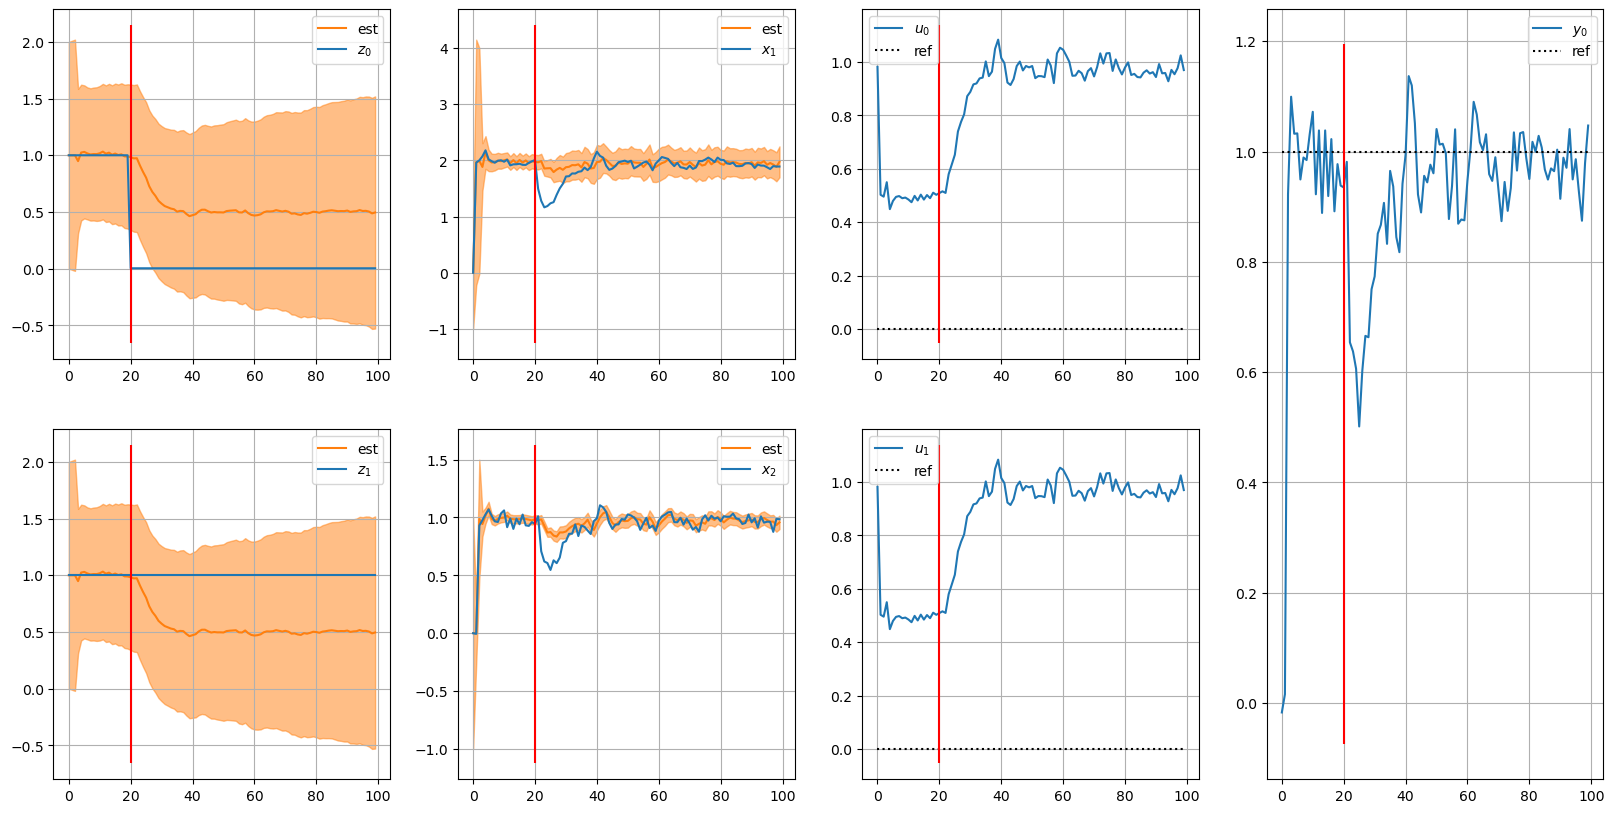

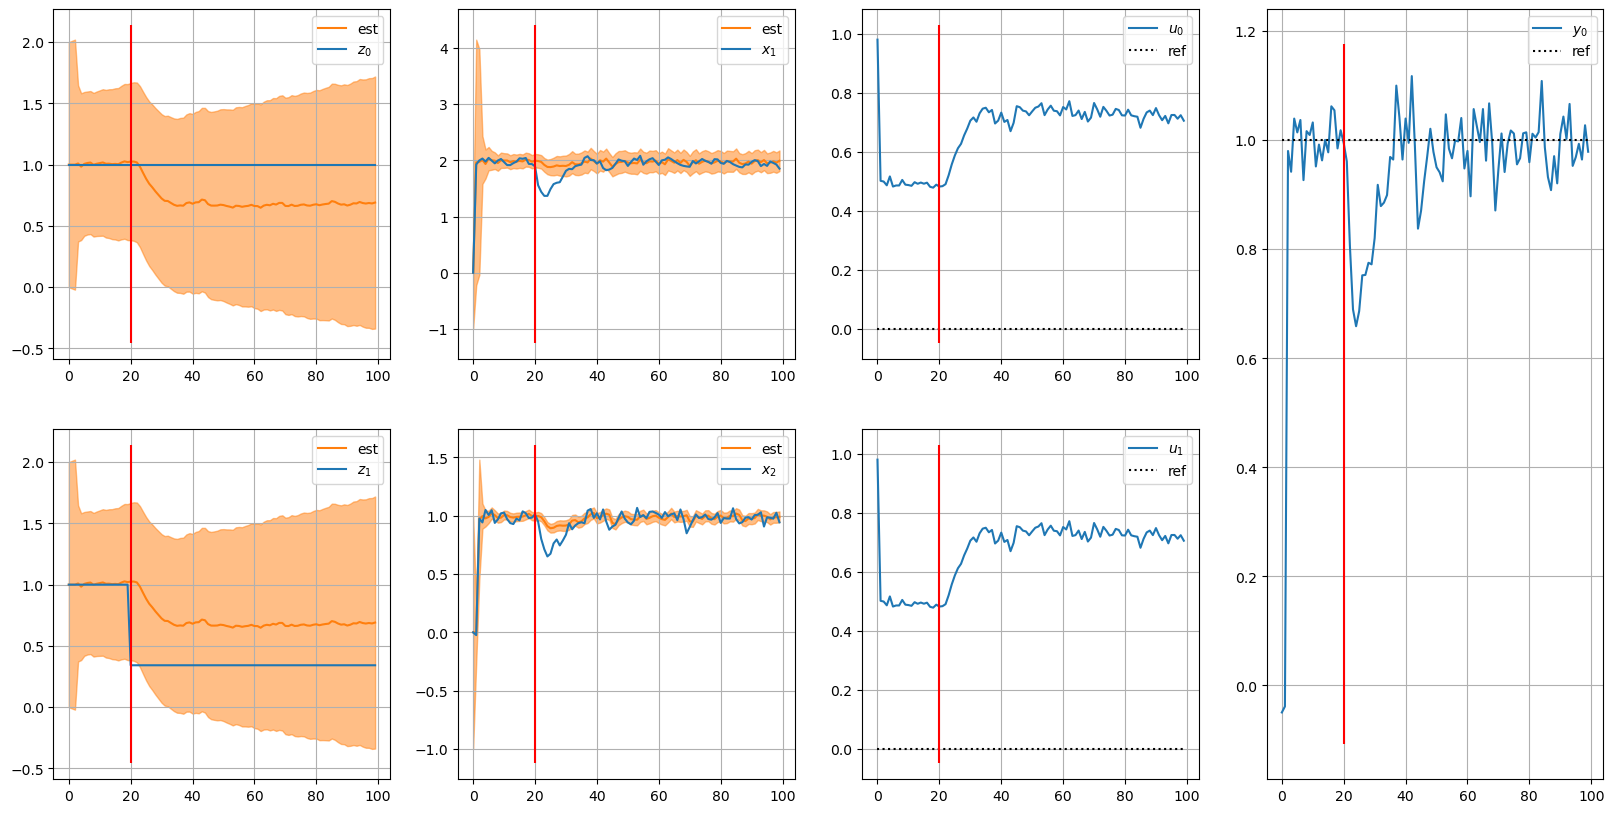

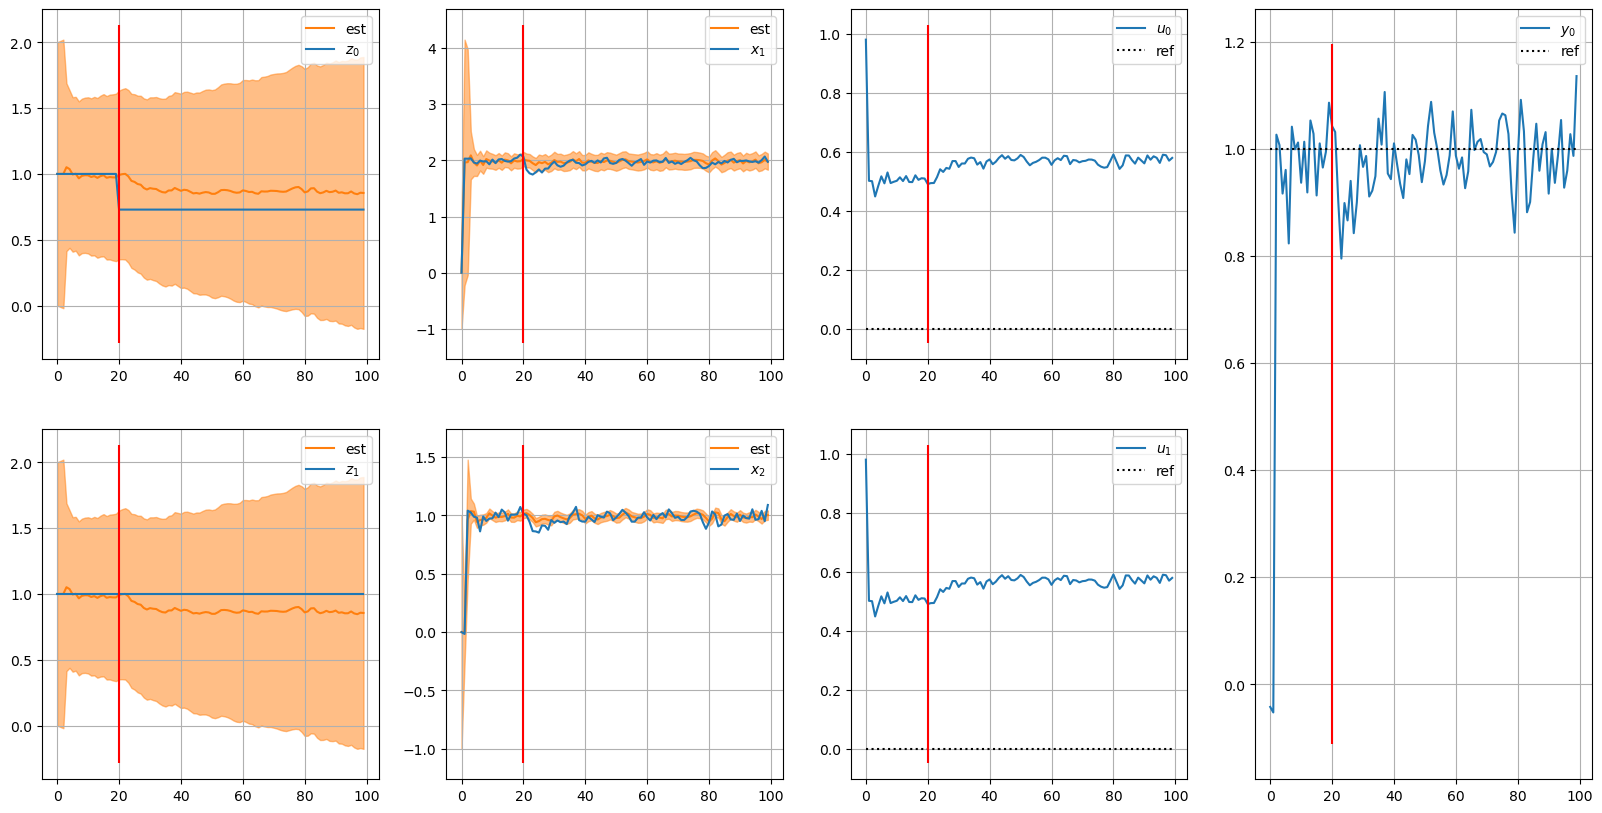

In [9]:
for seed in range(3):
    out = sim.rollout(rng=jr.key(seed))
    sim.plot(out)